In [1]:
%pylab inline

import jax
import jax.numpy as jnp
import tensorflow_probability as tfp; tfp = tfp.substrates.jax
tfd = tfp.distributions
tfb = tfp.bijectors

from jaxlie import SO3
from so3dm.distributions.isotropic_gaussian import IsotropicGaussianSO3
from so3dm.plotting import visualize_so3_probabilities

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## Create test distribution

In [313]:
def sample_checkerboard(batch_size, size=np.pi):
    x1 = np.random.rand(batch_size) * size - size/2
    x2_ = np.random.rand(batch_size) - np.random.randint(0, 2, batch_size) * 2
    x2 = x2_ + (np.floor(x1) % 2)
    data = np.concatenate([x1[:, None], x2[:, None]], 1) * size/2
    Rs = jax.jit(jax.vmap(lambda x: SO3.from_rpy_radians(pitch=x[0]/2, yaw=x[1], roll=0).as_matrix()))(data)
    return Rs

In [348]:
@jax.jit
@jax.vmap
def sample_checkerboard(seed, size=np.pi):
    key1, key2, key3 = jax.random.split(seed, 3)
    x1 = jax.random.uniform(key=key1) * size - size/2
    x2_ = jax.random.uniform(key=key2) - jax.random.randint(minval=0, maxval=2,shape=[], key=key3) * 2
    x2 = x2_ + (jnp.floor(x1) % 2)
    data = jnp.stack([x1, x2]) * size/2
    Rs = SO3.from_rpy_radians(pitch=data[0]/2, yaw=data[1], roll=0).as_matrix()
    return Rs

In [352]:
# Create a checkerboard grid
Rs = sample_checkerboard(jax.random.split(jax.random.PRNGKey(0), 1024))

In [353]:
Rs.shape

(1024, 3, 3)

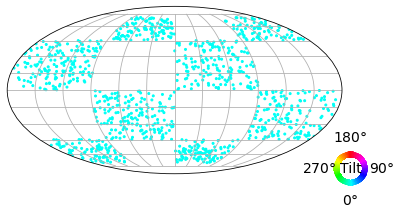

In [354]:
visualize_so3_probabilities(
    Rs,
    0.001);

## Create the noisy dataset

In [355]:
t = 1.
@jax.vmap
def score_comp(t):
    q0 = SO3.sample_uniform(jax.random.PRNGKey(0)).wxyz
    qn = IsotropicGaussianSO3(q0, jnp.sqrt(t)).sample(seed=jax.random.PRNGKey(1))
    
    def score_fn(x,t):
      def fn(s):
        return IsotropicGaussianSO3(q0, jnp.sqrt(t)).log_prob( (SO3(x) @ SO3.exp(s)).wxyz )
      return jax.grad(fn)(jnp.zeros(3))
    
    return score_fn(qn, t), (SO3(qn).inverse() @ SO3(q0)).log()/t

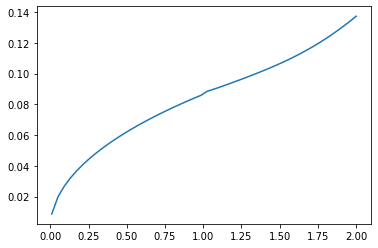

In [356]:
t = jnp.linspace(0.01,2)
s_lie, s_approx = score_comp(t)
plot(t, jnp.sum(abs(s_lie - s_approx),axis=-1) )

In [387]:
@jax.jit
@jax.vmap
def sample(R, scale, seed):
    x = SO3.from_matrix(R)
    dist = IsotropicGaussianSO3(x, scale)
    qn = dist.sample(seed=seed)
    
    def fn(s,q):
        return dist.log_prob( (SO3(q) @ SO3.exp(s)).wxyz)
    score = jax.grad(fn)(jnp.zeros(3), qn)
    
    return {'x': x.wxyz, 'y': qn, 'score': score, 's':scale}


@jax.jit
def get_batch(noise_dist_std, seed, batch_size=512):
    key1, key2 = jax.random.split(seed)
    # Sample from the target distribution
    Rs = sample_checkerboard(jax.random.split(key1, batch_size))
    
    # Sample standard deviation of noise corruption
    s = noise_dist_std * jnp.abs(randn(batch_size)) + 1e-2
    
    # Sample random rotations
    return sample(Rs, s, jax.random.split(key2, batch_size))

In [403]:
batch = get_batch(0.75, jax.random.PRNGKey(0))

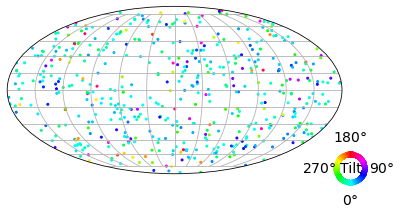

In [404]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(batch['y']),
    0.001);

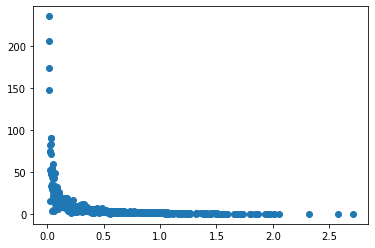

In [405]:
scatter(batch['s'], jnp.linalg.norm(batch['score'], axis=-1))


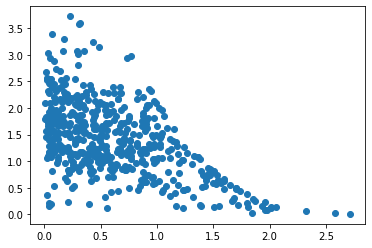

In [406]:
scatter(batch['s'], batch['s']*jnp.linalg.norm(batch['score'], axis=-1))

## Train a score network by denoising score matching

In [612]:
from so3dm.distributions.isotropic_gaussian import _isotropic_gaussian_so3_small
import haiku as hk
import optax

# Create a random sequence
rng_seq = hk.PRNGSequence(42)

In [613]:
def forward(x,s):
    net = jnp.concatenate([x,s],axis=-1)
    net = hk.nets.MLP([256, 256, 256], activation=jax.nn.leaky_relu)(net)
    net = hk.Linear(3)(net)
    return net/s

model = hk.without_apply_rng(hk.transform(forward))
params = model.init(jax.random.PRNGKey(0), jnp.zeros([1,4]),jnp.zeros([1,1]))

losses = []
totsteps=0
from flax.metrics import tensorboard
summary_writer = tensorboard.SummaryWriter('test')

In [636]:
optimizer = optax.adam(learning_rate=1e-4)

In [637]:
opt_state = optimizer.init(params)

In [638]:
def loss_fn(params, rng_key, batch):
    s = batch['s'].reshape([-1,1])
    score_pred = model.apply(params, batch['y'], s)
    
    loss = (batch['s']*jnp.linalg.norm(score_pred - batch['score'], axis=-1))**2
    
    return jnp.mean(loss)

In [639]:
@jax.jit
def update(params, rng_key, opt_state, batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng_key, batch)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, new_opt_state


In [651]:
for step in range(100000):
    batch = get_batch(0.8, seed=next(rng_seq))
    if isnan(batch['score'].mean()):
        continue
    loss, params, opt_state = update(params, next(rng_seq), opt_state, batch)
    totsteps+=1
    losses.append(loss)
    if isnan(loss):
        break
    if step % 5 ==0:
        summary_writer.scalar('train_loss', loss, totsteps)

In [652]:
# Try to sample with the trained model
nsamps = 4096
points = sample_checkerboard(jax.random.split(jax.random.PRNGKey(0), nsamps))
points = sample(points, 1*jnp.ones(nsamps), jax.random.split(jax.random.PRNGKey(2), nsamps))

@jax.jit
def dynamics(t, x):
  return - 0.5*model.apply(params,x,jnp.ones([nsamps,1])*jnp.sqrt(t))

In [653]:
y = points['y']
ts = jnp.linspace(1,0.001, 256)
h = (ts[1] - ts[0])
ys = [y]

# This is a simple implementation of a forward Euler integration scheme
for t in ts:
    dy = dynamics(t, y)
    y = jax.vmap(lambda u,v: (SO3(v) @ SO3.exp(u) ).wxyz)(h*dy,y)
    ys.append(y*1)

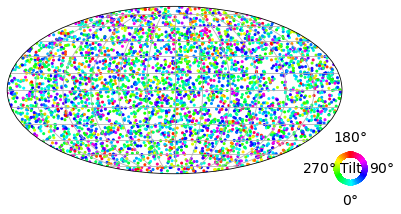

In [654]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(ys[0]),
    0.001);

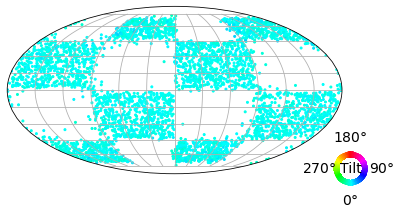

In [655]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(ys[-1]),
    0.001);

## Testing sampling by ODE from pure noise

In [656]:
points = jax.vmap(lambda k:SO3.sample_uniform(k).wxyz)(jax.random.split(jax.random.PRNGKey(42), 4096))

In [657]:
y = points
ts = jnp.linspace(2.,0.001, 512)
h = (ts[1] - ts[0])
ys = [y]

# This is a simple implementation of a forward Euler integration scheme
for t in ts:
    dy = dynamics(t, y)
    y = jax.vmap(lambda u,v: (SO3(v) @ SO3.exp(u) ).wxyz)(h*dy,y)
    ys.append(y*1)

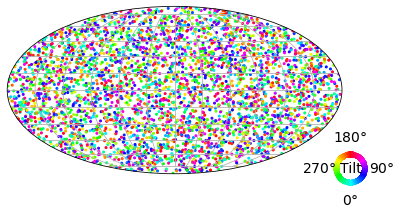

In [658]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(ys[0]),
    0.001);

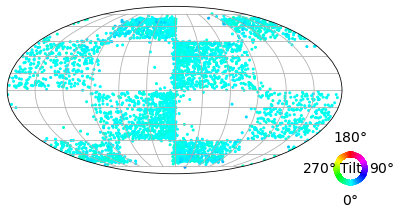

In [659]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(ys[-1]),
    0.001);

In [660]:
# The following is borrowed from https://github.com/ericjang/nf-jax/blob/master/nf-tutorial-jax.ipynb
from matplotlib import animation, rc
# from IPython.display import HTML, Image
# equivalent to rcParams['animation.html'] = 'html5'
rc('animation', html='html5')

def visualize_so3_probabilities(rotations,
                                probabilities,
                                rotations_gt=None,
                                ax=None,
                                fig=None,
                                paths=None,
                                show_color_wheel=True,
                                canonical_rotation=np.eye(3)):
  """Plot a single distribution on SO(3) using the tilt-colored method.

  Args:
    rotations: [N, 3, 3] tensor of rotation matrices
    probabilities: [N] tensor of probabilities
    rotations_gt: [N_gt, 3, 3] or [3, 3] ground truth rotation matrices
    ax: The matplotlib.pyplot.axis object to paint
    fig: The matplotlib.pyplot.figure object to paint
    show_color_wheel: If True, display the explanatory color wheel which matches
      color on the plot with tilt angle
    canonical_rotation: A [3, 3] rotation matrix representing the 'display
      rotation', to change the view of the distribution.  It rotates the
      canonical axes so that the view of SO(3) on the plot is different, which
      can help obtain a more informative view.
  Returns:
    A matplotlib.pyplot.figure object, or a tensor of pixels if to_image=True.
  """
  def _show_single_marker(ax, rotation, marker, edgecolors=True,
                          facecolors=False):
    eulers = SO3.from_matrix(rotation).as_rpy_radians()
    xyz = rotation[:, 0]
    tilt_angle = eulers[0]
    longitude = np.arctan2(xyz[0], -xyz[1])
    latitude = np.arcsin(xyz[2])

    color = cmap(0.5 + tilt_angle / 2 / np.pi)
    ax.scatter(longitude, latitude, s=2500,
               edgecolors=color if edgecolors else 'none',
               facecolors=facecolors if facecolors else 'none',
               marker=marker,
               linewidth=4)

  if ax is None:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='mollweide')
  if rotations_gt is not None and len(rotations_gt.shape) == 2:
    rotations_gt = jnp.expand_dims(rotations_gt,axis=0)

  display_rotations = rotations @ canonical_rotation
  cmap = plt.cm.hsv
  scatterpoint_scaling = 4e3
  eulers_queries = jax.vmap(lambda x: SO3.from_matrix(x).as_rpy_radians())(display_rotations)
  xyz = display_rotations[:, :, 0]
  tilt_angles = eulers_queries.roll

  longitudes = np.arctan2(xyz[:, 0], -xyz[:, 1])
  latitudes = np.arcsin(xyz[:, 2])
  if paths is not None:
    paths.set_offsets(np.stack([longitudes, latitudes], axis=-1))
    paths.set_color(cmap(0.5 + tilt_angles / 2. / np.pi))
    return paths
    
#   which_to_display = (probabilities > display_threshold_probability)

  if rotations_gt is not None:
    # The visualization is more comprehensible if the GT
    # rotation markers are behind the output with white filling the interior.
    display_rotations_gt = rotations_gt @ canonical_rotation

    for rotation in display_rotations_gt:
      _show_single_marker(ax, rotation, 'o')
    # Cover up the centers with white markers
    for rotation in display_rotations_gt:
      _show_single_marker(ax, rotation, 'o', edgecolors=False,
                          facecolors='#ffffff')

  # Display the distribution
  paths = ax.scatter(
      longitudes,
      latitudes,
      s=scatterpoint_scaling * probabilities,
      c=cmap(0.5 + tilt_angles / 2. / np.pi))

  ax.grid()
  ax.set_xticklabels([])
  ax.set_yticklabels([])

  if show_color_wheel:
    # Add a color wheel showing the tilt angle to color conversion.
    ax = fig.add_axes([0.86, 0.17, 0.12, 0.12], projection='polar')
    theta = np.linspace(-3 * np.pi / 2, np.pi / 2, 200)
    radii = np.linspace(0.4, 0.5, 2)
    _, theta_grid = np.meshgrid(radii, theta)
    colormap_val = 0.5 + theta_grid / np.pi / 2.
    ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
    ax.set_yticklabels([])
    ax.set_xticklabels([r'90$\degree$', None,
                        r'180$\degree$', None,
                        r'270$\degree$', None,
                        r'0$\degree$'], fontsize=14)
    ax.spines['polar'].set_visible(False)
    plt.text(0.5, 0.5, 'Tilt', fontsize=14,
             horizontalalignment='center',
             verticalalignment='center', transform=ax.transAxes)
  return paths

/tmp/ipykernel_173344/178043303.py:99: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
/tmp/ipykernel_173344/178043303.py:101: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'90$\degree$', None,


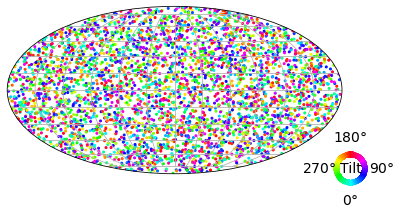

In [666]:
fig = plt.figure()
ax = fig.add_subplot( projection='mollweide')

paths = visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(ys[0]),
    0.001,
    fig=fig,
    ax=ax)

def animate(i):
  visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(ys[min(i,511)]),
    0.001,
    fig=fig,
    ax=ax,
    paths=paths)
  return (paths,)

anim = animation.FuncAnimation(fig, animate, frames=1024, interval=10, blit=False)

In [667]:
anim